# ASX Stock Performance Predictor
 A machine learning project to predict next-day stock price direction for ASX-listed companies.


## v2 Changes
- Changed data range from 5y to 10y
- Hypothesis: more data would help the model learn more patterns
- Result: accuracy dropped from 48.8% to 46.9%
- Conclusion: older MQG data introduces noise, reverting to 5y in v3

## 1. Install & Import Libraries


In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import sqlite3

## 2. Download ASX Stock Data



In [35]:
ticker = input("Enter ASX ticker symbol (e.g. For Macquarie Group Enter: MQG): ")
stock = yf.Ticker(ticker + ".AX")
df = stock.history(period="10y") 
df = df.sort_index(ascending=False)
df.index = df.index.tz_localize(None)
df.head(10)

Enter ASX ticker symbol (e.g. For Macquarie Group Enter: MQG):  MQG


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-09,192.399994,196.139999,189.869995,195.449997,1127663,0.0,0.0
2026-03-06,196.699997,201.279999,194.800003,200.300003,979569,0.0,0.0
2026-03-05,195.089996,198.860001,194.539993,198.860001,1246062,0.0,0.0
2026-03-04,196.029999,196.899994,191.529999,191.529999,1103437,0.0,0.0
2026-03-03,200.210007,202.440002,195.779999,196.470001,1168746,0.0,0.0
2026-03-02,204.009995,204.494995,198.500000,199.860001,1461442,0.0,0.0
2026-02-27,210.000000,213.639999,209.839996,213.479996,1178563,0.0,0.0
2026-02-26,211.000000,211.100006,208.880005,209.550003,580711,0.0,0.0
2026-02-25,207.699997,208.190002,205.679993,207.119995,959862,0.0,0.0


## 3. Store Data in SQLite Database



In [36]:
# Connect to local SQLite database
conn = sqlite3.connect("asx_stocks.db")
df.to_sql(ticker.lower(), conn, if_exists="replace", index=True)
print(f"Data saved for {ticker}.AX!")

Data saved for MQG.AX!


In [37]:
# Query database to check data was saved correctly
query = f"""
SELECT * FROM {ticker.lower()}
ORDER BY "Date" DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)

                  Date        Open        High         Low       Close  \
0  2026-03-09 00:00:00  192.399994  196.139999  189.869995  195.449997   
1  2026-03-06 00:00:00  196.699997  201.279999  194.800003  200.300003   
2  2026-03-05 00:00:00  195.089996  198.860001  194.539993  198.860001   
3  2026-03-04 00:00:00  196.029999  196.899994  191.529999  191.529999   
4  2026-03-03 00:00:00  200.210007  202.440002  195.779999  196.470001   
5  2026-03-02 00:00:00  204.009995  204.494995  198.500000  199.860001   
6  2026-02-27 00:00:00  210.000000  213.639999  209.839996  213.479996   
7  2026-02-26 00:00:00  211.000000  211.100006  208.880005  209.550003   
8  2026-02-25 00:00:00  207.699997  208.190002  205.679993  207.119995   
9  2026-02-24 00:00:00  204.500000  207.630005  201.250000  206.490005   

    Volume  Dividends  Stock Splits  
0  1127663        0.0           0.0  
1   979569        0.0           0.0  
2  1246062        0.0           0.0  
3  1103437        0.0           0

## 4. Engineer Features



In [38]:
# Calculate moving averages (MA) to smooth out short term price noise
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA30"] = df["Close"].rolling(window=30).mean()

# Calculate momentum over last 7 days
df["Momentum"] = df["Close"] - df["Close"].shift(7)

# Calculate Target Variable: 1 if tomorrows price is higher than today, 0 if not
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

df.head(10)


,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA7,MA30,Momentum,Target
Date,,,,,,,,,,,
2026-03-09,192.399994,196.139999,189.869995,195.449997,1127663,0.0,0.0,NaN,NaN,NaN,1
2026-03-06,196.699997,201.279999,194.800003,200.300003,979569,0.0,0.0,NaN,NaN,NaN,0
2026-03-05,195.089996,198.860001,194.539993,198.860001,1246062,0.0,0.0,NaN,NaN,NaN,0
2026-03-04,196.029999,196.899994,191.529999,191.529999,1103437,0.0,0.0,NaN,NaN,NaN,1
2026-03-03,200.210007,202.440002,195.779999,196.470001,1168746,0.0,0.0,NaN,NaN,NaN,1
2026-03-02,204.009995,204.494995,198.500000,199.860001,1461442,0.0,0.0,NaN,NaN,NaN,1
2026-02-27,210.000000,213.639999,209.839996,213.479996,1178563,0.0,0.0,199.421428,NaN,NaN,0
2026-02-26,211.000000,211.100006,208.880005,209.550003,580711,0.0,0.0,201.435715,NaN,14.100006,0
2026-02-25,207.699997,208.190002,205.679993,207.119995,959862,0.0,0.0,202.409999,NaN,6.819992,0


In [39]:
# Drop rows with missing values, check shape
df = df.dropna()
df.shape

(2501, 11)

## 5. Train the Model



In [40]:
# Define features and target
features = ["Close", "MA7", "MA30", "Momentum", "Volume"]
X = df[features]
y = df["Target"]


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train.shape, X_test.shape

((2000, 5), (501, 5))

In [42]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=6)
model_name = "Random Forest 100 trees"
model.fit(X_train, y_train)

print("Model Trained!")

Model Trained!


## 6. Evaluate & Visualise Results



In [43]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on test set
y_pred = model.predict(X_test)

# Check accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.469061876247505
              precision    recall  f1-score   support

           0       0.56      0.19      0.28       277
           1       0.45      0.81      0.58       224

    accuracy                           0.47       501
   macro avg       0.50      0.50      0.43       501
weighted avg       0.51      0.47      0.42       501



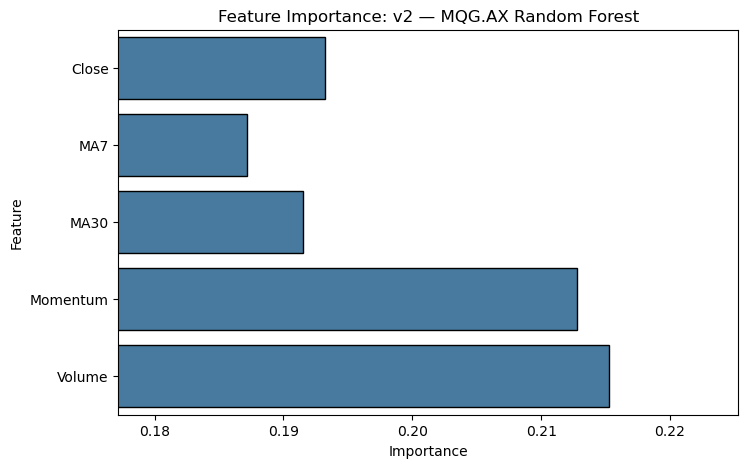

In [47]:
# Plot feature importance - visualise which features the model relied on most
feature_importance = pd.Series(model.feature_importances_, index=features)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, color="#397dad", edgecolor="black")
plt.title(f"Feature Importance: v2 — {ticker}.AX Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.xlim(feature_importance.min() - 0.01, feature_importance.max() + 0.01)
plt.show()

In [45]:
conn2 = sqlite3.connect("asx_stocks.db")
log = pd.DataFrame({
    "version": ["v2"],
    "accuracy": [accuracy_score(y_test, y_pred)],
    "model": [model_name],
    "notes": ["Increased data to 10y — accuracy dropped, older data adds noise"]
})
log.to_sql("progress_log", conn2, if_exists="append", index=False)
conn2.close()
print("v2 logged!")


v2 logged!
